# FFT Option Pricing: Black-Scholes-Merton, Heston & Variance Gamma

This notebook implements the Carr-Madan (1999) Fast Fourier Transform method to price European options under three asset pricing models. Each model makes different assumptions about how asset prices behave, and those assumptions show up directly in the prices they produce.

The goal here is not just to compute prices, but to *see* why these models exist and when you would reach for one over another.

## Why Do We Need More Than Black-Scholes?

The Black-Scholes-Merton (BMS) model assumes that asset returns are normally distributed with constant volatility. This is elegant and gives us a closed-form pricing formula, but markets consistently violate this assumption in two ways:

1. **The volatility smile.** If BMS were correct, implied volatility would be flat across all strikes. Instead, out-of-the-money puts trade at higher implied volatilities than at-the-money options. After the 1987 crash, this pattern became permanent in equity markets.

2. **Fat tails and jumps.** Real asset returns have more extreme moves than a normal distribution predicts. The 2008 financial crisis, the 2020 COVID crash, and daily flash crashes all involve moves that BMS assigns near-zero probability.

The Heston and Variance Gamma models each address these problems differently.

## The Three Models at a Glance

| | **Black-Scholes-Merton** | **Heston** | **Variance Gamma** |
|---|---|---|---|
| **Core idea** | Price follows geometric Brownian motion with constant volatility | Volatility itself is a random process that mean-reverts | Time passes randomly — activity comes in bursts separated by quiet periods |
| **Volatility** | Constant | Stochastic, mean-reverting (CIR process) | Constant conditional on time change, but effective vol varies |
| **Returns distribution** | Normal (symmetric, thin tails) | Skewed via $\rho$, heavier tails via vol-of-vol | Fat-tailed and skewed via $\theta$ and $\nu$ |
| **Key parameters** | $\sigma$ | $\kappa$ (mean reversion), $\theta$ (long-run var), $\lambda$ (vol-of-vol), $\rho$ (correlation), $v_0$ (initial var) | $\sigma$ (vol), $\nu$ (kurtosis/tail weight), $\theta$ (skewness) |
| **Captures smile?** | No — produces flat implied vol | Yes — $\rho < 0$ creates the skew | Yes — $\nu > 0$ creates fat tails, $\theta < 0$ creates skew |
| **Number of params** | 1 | 5 | 3 |

## Where Each Model Gets Used in Practice

**Black-Scholes-Merton** remains the lingua franca of options markets. Traders quote prices in terms of BMS implied volatility even when they know the model is wrong. It is the benchmark everything else is measured against, and for at-the-money options with short maturities, it is often good enough.

**Heston** is widely used on equity derivatives desks and in risk management systems. Its ability to capture the volatility smile through a single correlation parameter ($\rho$) makes it the go-to model when you need smile-consistent pricing without leaving the diffusion framework. Banks use it for pricing exotic equity options, computing Greeks, and calibrating local volatility surfaces.

**Variance Gamma** shows up in credit derivatives, commodity markets, and anywhere returns exhibit distinct jumps or clustering of activity. It is part of the Lévy process family and naturally produces the fat tails observed in high-frequency return data. VG is also used for modeling operational risk and portfolio credit risk, where extreme losses matter more than day-to-day fluctuations.

## How We Price: The Carr-Madan FFT Approach

All three models have known characteristic functions — closed-form expressions for $\phi(u) = \mathbb{E}[e^{iu \ln S_T}]$. The Carr-Madan method exploits this: instead of integrating the payoff against the density directly (which may not have a closed form), we work in Fourier space where the characteristic function *is* the density's transform.

The FFT computes option prices at $N$ strikes simultaneously in $O(N \log N)$ time. A single FFT call gives you an entire option price curve — not just one price at one strike.

The details of the derivation are covered in the companion notebook. Here we implement and visualize the results.

---

# Part 1: Setup and Model Definitions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from time import time

# plot styling
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

### Lognormal Density

Under BMS, the stock price at maturity is lognormally distributed. This density is used for the numerical integration baseline.

In [ ]:
def logNormal(S, r, q, sig, S0, T):
    """Lognormal density function for the stock price under BMS."""
    f = np.exp(-0.5*((np.log(S/S0)-(r-q-sig**2/2)*T)/(sig*np.sqrt(T)))**2) / (sig*S*np.sqrt(2*np.pi*T))
    return f

### Characteristic Functions

Each model is defined by its characteristic function $\phi(u)$. This is the only model-specific piece — the FFT pricing engine is completely generic.

In [ ]:
def generic_CF(u, params, S0, r, q, T, model):
    """Characteristic function of the log-stock price for BMS, Heston, and VG models."""

    if (model == 'BMS'):
        sig = params[0]
        mu = np.log(S0) + (r-q-sig**2/2)*T
        a = sig*np.sqrt(T)
        phi = np.exp(1j*mu*u-(a*u)**2/2)

    elif(model == 'Heston'):
        kappa  = params[0]
        theta  = params[1]
        sigma  = params[2]
        rho    = params[3]
        v0     = params[4]
        tmp = (kappa-1j*rho*sigma*u)
        g = np.sqrt((sigma**2)*(u**2+1j*u)+tmp**2)
        pow1 = 2*kappa*theta/(sigma**2)
        numer1 = (kappa*theta*T*tmp)/(sigma**2) + 1j*u*T*r + 1j*u*np.log(S0)
        log_denum1 = pow1 * np.log(np.cosh(g*T/2)+(tmp/g)*np.sinh(g*T/2))
        tmp2 = ((u*u+1j*u)*v0)/(g/np.tanh(g*T/2)+tmp)
        log_phi = numer1 - log_denum1 - tmp2
        phi = np.exp(log_phi)

    elif (model == 'VG'):
        sigma  = params[0]
        nu     = params[1]
        theta  = params[2]
        if (nu == 0):
            mu = np.log(S0) + (r-q - theta -0.5*sigma**2)*T
            phi  = np.exp(1j*u*mu) * np.exp((1j*theta*u-0.5*sigma**2*u**2)*T)
        else:
            mu  = np.log(S0) + (r-q + np.log(1-theta*nu-0.5*sigma**2*nu)/nu)*T
            phi = np.exp(1j*u*mu)*((1-1j*nu*theta*u+0.5*nu*sigma**2*u**2)**(-T/nu))

    return phi

### FFT Pricing Engine

This is the Carr-Madan algorithm. It takes *any* model's characteristic function and returns option prices across an entire grid of strikes in a single FFT call.

In [ ]:
def genericFFT(params, S0, K, r, q, T, alpha, eta, n, model):
    """Option pricing using the Carr-Madan FFT method (model-agnostic)."""

    N = 2**n

    # step-size in log strike space
    lda = (2 * np.pi / N) / eta

    # choice of beta — log strike we want is the first element
    beta = np.log(K)

    # discount factor
    df = np.exp(-r*T)

    # Fourier grid
    nuJ = np.arange(N) * eta
    psi_nuJ = generic_CF(nuJ - (alpha + 1) * 1j, params, S0, r, q, T, model) / ((alpha + 1j*nuJ)*(alpha+1+1j*nuJ))

    # log-strike grid
    km = beta + lda * np.arange(N)

    # trapezoidal weights
    w = eta * np.ones(N)
    w[0] = eta / 2

    # form the x vector and apply FFT
    xX = np.exp(-1j * beta * nuJ) * df * psi_nuJ * w
    yY = np.fft.fft(xX)

    # recover option prices
    multiplier = np.exp(-alpha * km) / np.pi
    cT_km = multiplier * np.real(yY)

    return km, cT_km

---

# Part 2: Numerical Integration Baseline

Before using the FFT, we establish a baseline by pricing a European put through direct numerical integration of the lognormal density. This shows how the price converges as we refine the grid — and why the FFT is a better approach.

In [ ]:
def numerical_integral_put(r, q, S0, K, sig, T, N):
    """Price a European put by numerical integration of the lognormal density."""
    df = np.exp(-r * T)
    eta = 1. * K / N
    S = np.arange(0, N) * eta
    S[0] = 1e-8  # avoid log(0)
    w = np.ones(N) * eta
    w[0] = eta / 2
    logN = logNormal(S, r, q, sig, S0, T)
    sumP = np.sum((K - S) * logN * w)
    priceP = df * sumP
    return eta, priceP

In [ ]:
# baseline parameters
S0_base = 100
K_base = 90
r_base = 0.04
q_base = 0.02
sig_base = 0.25
T_base = 1.0

# compute put price for N = 2^1 through 2^15
n_min, n_max = 1, 15
n_vec_base = np.arange(n_min, n_max + 1, dtype=int)
put_vec_base = np.zeros(n_max)

for i in range(n_max):
    N = 2 ** n_vec_base[i]
    _, put_vec_base[i] = numerical_integral_put(r_base, q_base, S0_base, K_base, sig_base, T_base, N)

### Convergence of Numerical Integration

**Why this matters:** Before trusting any model's output, you need to know your numerical method has actually converged. On a trading desk, a pricing engine that hasn't converged might show a put worth 0.48 when it's really worth 4.52 — that's the difference between passing on a trade and making a serious hedging error. This plot is the kind of sanity check a quant runs before deploying a new pricer.

**What to notice:** The price stabilizes around $N = 2^9$ (512 grid points). Beyond that, adding more points doesn't change the answer. The FFT will give us this same accuracy with far less computational effort — and for an entire curve of strikes at once.

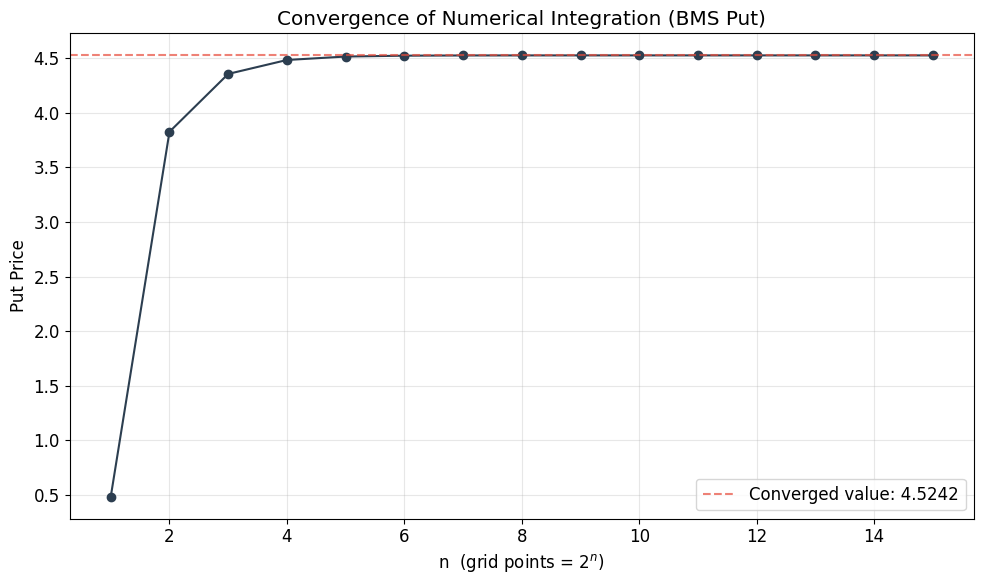

In [ ]:
fig, ax = plt.subplots()
ax.plot(n_vec_base, put_vec_base, 'o-', color='#2C3E50', markersize=6, linewidth=1.5)
ax.axhline(y=put_vec_base[-1], color='#E74C3C', linestyle='--', alpha=0.7, label=f'Converged value: {put_vec_base[-1]:.4f}')
ax.set_xlabel('n  (grid points = $2^n$)')
ax.set_ylabel('Put Price')
ax.set_title('Convergence of Numerical Integration (BMS Put)')
ax.legend()
plt.tight_layout()
plt.show()

---

# Part 3: FFT Pricing Across All Three Models

Now we use the FFT to price puts under BMS, Heston, and Variance Gamma. The power of this approach is that the *same engine* prices options under any model — you just swap out the characteristic function.

In [ ]:
# common parameters
S0 = 100
K = 80
r = 0.05
q = 0.01
T = 1.0

# FFT parameters (stable choices)
alpha = -1.5
eta = 0.25
n = 10  # N = 1024 points

# model parameters
bms_params = [0.3]                              # sigma
heston_params = [2., 0.05, 0.3, -0.7, 0.04]    # kappa, theta, lambda, rho, v0
vg_params = [0.3, 0.5, -0.4]                    # sigma, nu, theta

In [ ]:
# price under all three models
km_bms, prices_bms = genericFFT(bms_params, S0, K, r, q, T, alpha, eta, n, 'BMS')
km_hes, prices_hes = genericFFT(heston_params, S0, K, r, q, T, alpha, eta, n, 'Heston')
km_vg,  prices_vg  = genericFFT(vg_params, S0, K, r, q, T, alpha, eta, n, 'VG')

# convert log-strikes to strikes
strikes_bms = np.exp(km_bms)
strikes_hes = np.exp(km_hes)
strikes_vg  = np.exp(km_vg)

### Put Prices Across Strikes

**Why this matters:** Imagine you're a portfolio manager who owns \$10M in equities and wants to buy put options as downside protection. The model you choose directly determines how much that insurance costs. If you price your hedges with Black-Scholes but the market prices them with something closer to Heston, you'll consistently underpay for protection — or worse, think you're hedged when you're not. This chart shows you exactly where model choice changes the dollar amount on the ticket.

**What to notice:** All three models agree near the at-the-money region ($K \approx S_0 = 100$). The differences show up in the tails — particularly for deep out-of-the-money puts ($K \ll S_0$). Variance Gamma produces the highest OTM put prices because its fat tails assign more probability to extreme downward moves. Heston sits in between, with its skew driven by the negative price-vol correlation ($\rho = -0.7$).

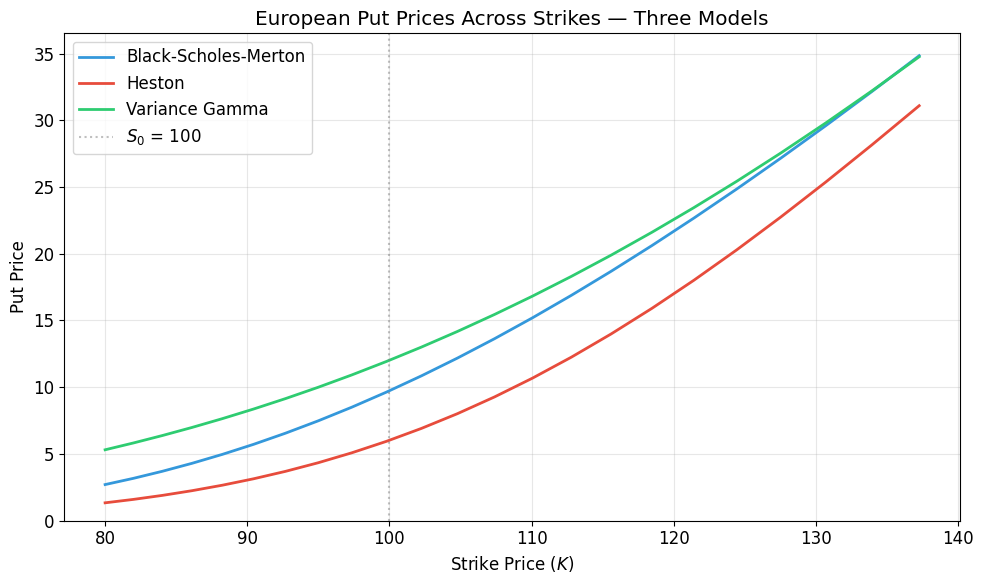

In [ ]:
# define a reasonable strike range for plotting
k_min, k_max = 60, 140

mask_bms = (strikes_bms >= k_min) & (strikes_bms <= k_max)
mask_hes = (strikes_hes >= k_min) & (strikes_hes <= k_max)
mask_vg  = (strikes_vg >= k_min)  & (strikes_vg <= k_max)

fig, ax = plt.subplots()
ax.plot(strikes_bms[mask_bms], prices_bms[mask_bms], linewidth=2, label='Black-Scholes-Merton', color='#3498DB')
ax.plot(strikes_hes[mask_hes], prices_hes[mask_hes], linewidth=2, label='Heston', color='#E74C3C')
ax.plot(strikes_vg[mask_vg],   prices_vg[mask_vg],   linewidth=2, label='Variance Gamma', color='#2ECC71')
ax.axvline(x=S0, color='gray', linestyle=':', alpha=0.5, label=f'$S_0$ = {S0}')
ax.set_xlabel('Strike Price ($K$)')
ax.set_ylabel('Put Price')
ax.set_title('European Put Prices Across Strikes — Three Models')
ax.legend()
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

### Implied Risk-Neutral Densities (Breeden-Litzenberger)

The risk-neutral density $q(K)$ tells you the market's implied probability of the stock ending at each price level. We extract it from call prices using the Breeden-Litzenberger result:

$$q(K) = e^{rT} \frac{\partial^2 C}{\partial K^2}$$

We approximate the second derivative numerically from the FFT output.

**Why this matters:** Risk managers at banks use these densities to stress-test portfolios. If your model says there's a 0.01% chance of a 30% crash but history says it's more like 1%, your Value-at-Risk numbers are dangerously optimistic. During the 2008 crisis, firms using BMS-based risk models systematically underestimated tail risk. This chart shows you *exactly* how much probability each model puts on extreme outcomes — and why the choice matters when billions of dollars are at stake.

**What to notice:** BMS produces a clean, symmetric lognormal bell. Heston's density is skewed left (more weight on downside moves) because $\rho < 0$ links falling prices to rising volatility. Variance Gamma has the fattest tails — it assigns meaningful probability to extreme moves that BMS essentially ignores.

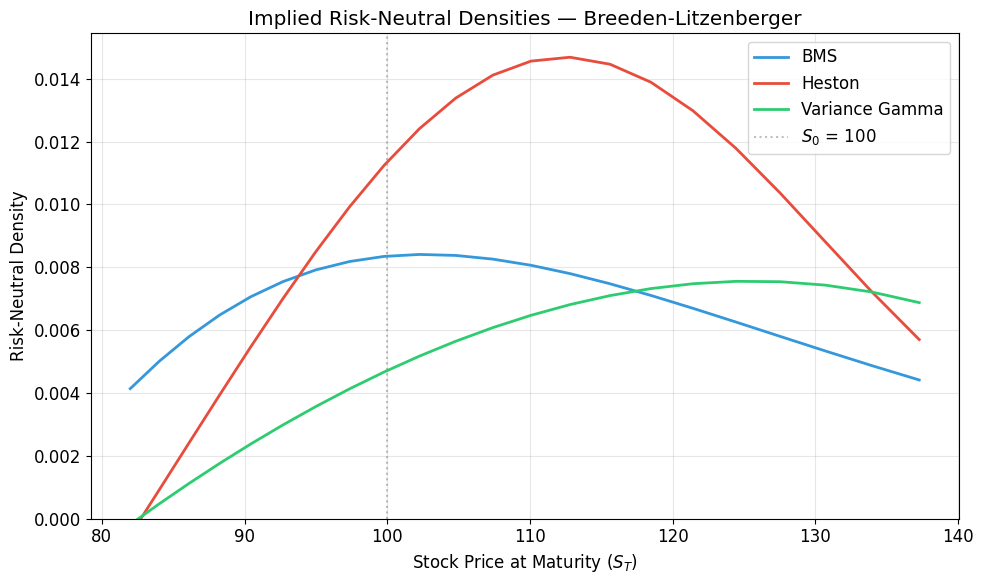

In [ ]:
def extract_density(km, prices, r, T):
    """Extract risk-neutral density via Breeden-Litzenberger (numerical second derivative)."""
    strikes = np.exp(km)
    # convert puts to calls via put-call parity for cleaner numerics
    df = np.exp(-r * T)
    S_fwd = S0 * np.exp((r - q) * T)
    calls = prices + df * (S_fwd - strikes)
    # second derivative of call price w.r.t. strike
    dK = np.diff(strikes)
    d2C = np.diff(calls, n=2) / (dK[:-1] * dK[1:])
    density = np.exp(r * T) * d2C
    # midpoint strikes for plotting
    k_mid = strikes[1:-1]
    return k_mid, density

k_d_bms, dens_bms = extract_density(km_bms, prices_bms, r, T)
k_d_hes, dens_hes = extract_density(km_hes, prices_hes, r, T)
k_d_vg,  dens_vg  = extract_density(km_vg,  prices_vg,  r, T)

fig, ax = plt.subplots()
mask_d_bms = (k_d_bms >= k_min) & (k_d_bms <= k_max)
mask_d_hes = (k_d_hes >= k_min) & (k_d_hes <= k_max)
mask_d_vg  = (k_d_vg >= k_min)  & (k_d_vg <= k_max)

ax.plot(k_d_bms[mask_d_bms], dens_bms[mask_d_bms], linewidth=2, label='BMS', color='#3498DB')
ax.plot(k_d_hes[mask_d_hes], dens_hes[mask_d_hes], linewidth=2, label='Heston', color='#E74C3C')
ax.plot(k_d_vg[mask_d_vg],   dens_vg[mask_d_vg],   linewidth=2, label='Variance Gamma', color='#2ECC71')
ax.axvline(x=S0, color='gray', linestyle=':', alpha=0.5, label=f'$S_0$ = {S0}')
ax.set_xlabel('Stock Price at Maturity ($S_T$)')
ax.set_ylabel('Risk-Neutral Density')
ax.set_title('Implied Risk-Neutral Densities — Breeden-Litzenberger')
ax.legend()
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

---

# Part 4: Parameter Sensitivity

Understanding *what each parameter does* is more valuable than memorizing the formulas. Below we vary one parameter at a time and watch how the put price curve responds.

### Heston: Effect of Price-Volatility Correlation ($\rho$)

**Why this matters:** In March 2020, as COVID fears triggered a 34% drop in the S&P 500, the VIX (a measure of implied volatility) spiked from 14 to 82 — its highest reading ever. Prices fell and volatility exploded simultaneously. This is the leverage effect, and it is exactly what Heston's $\rho$ parameter captures. Equity derivatives desks calibrate $\rho$ daily because it directly determines how much crash protection (OTM puts) costs. A desk that gets $\rho$ wrong misprices every downside hedge they sell.

**What to notice:** When $\rho$ is strongly negative, falling stock prices coincide with rising volatility — this makes OTM puts more expensive because crashes come with volatility spikes. When $\rho = 0$, the smile becomes symmetric. Positive $\rho$ would create a skew in the other direction (rare in equities, sometimes seen in commodities where supply shocks drive prices up and volatility up simultaneously).

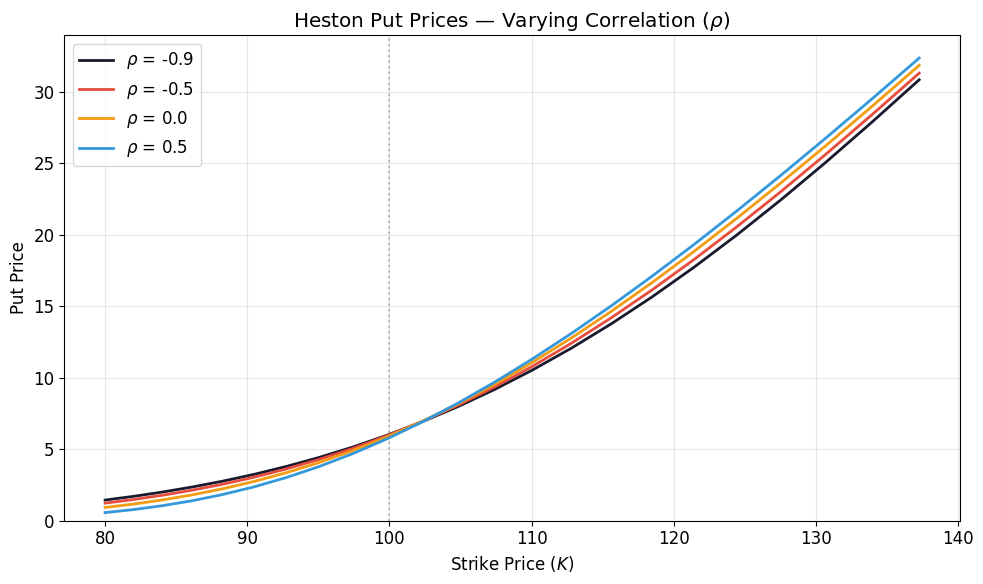

In [ ]:
rho_values = [-0.9, -0.5, 0.0, 0.5]
colors_rho = ['#1A1A2E', '#E74C3C', '#F39C12', '#3498DB']

fig, ax = plt.subplots()
for rho_val, col in zip(rho_values, colors_rho):
    params_rho = [2., 0.05, 0.3, rho_val, 0.04]
    km_rho, prices_rho = genericFFT(params_rho, S0, K, r, q, T, alpha, eta, n, 'Heston')
    strikes_rho = np.exp(km_rho)
    mask_rho = (strikes_rho >= k_min) & (strikes_rho <= k_max)
    ax.plot(strikes_rho[mask_rho], prices_rho[mask_rho], linewidth=2,
            label=f'$\\rho$ = {rho_val}', color=col)

ax.axvline(x=S0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Strike Price ($K$)')
ax.set_ylabel('Put Price')
ax.set_title('Heston Put Prices — Varying Correlation ($\\rho$)')
ax.legend()
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

### Variance Gamma: Effect of Skewness ($\theta$)

**Why this matters:** Credit default swaps and corporate bond spreads are priced on models that need to capture the asymmetry of default risk — companies can gradually appreciate but they blow up suddenly. The VG skewness parameter $\theta$ lets you dial in exactly how asymmetric the return distribution is. When a credit analyst at a bank prices a portfolio of corporate bonds, getting $\theta$ right determines whether they are accurately reserving capital for potential losses or sitting on hidden risk.

**What to notice:** $\theta < 0$ introduces negative skewness — the Brownian motion drifts downward before the time change, making large losses more likely. As $\theta$ becomes more negative, OTM put prices increase. At $\theta = 0$, the VG process is symmetric.

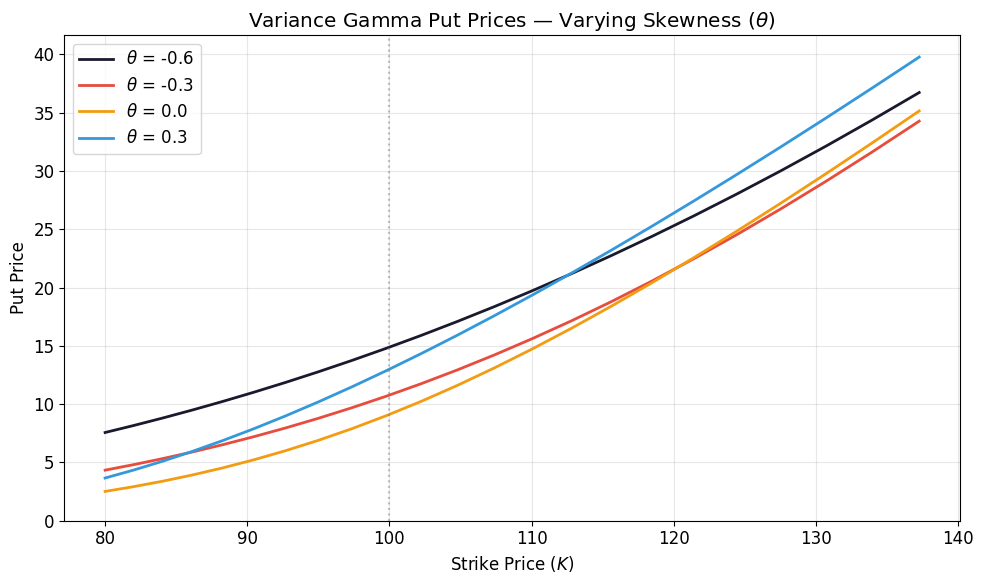

In [ ]:
theta_values = [-0.6, -0.3, 0.0, 0.3]
colors_theta = ['#1A1A2E', '#E74C3C', '#F39C12', '#3498DB']

fig, ax = plt.subplots()
for theta_val, col in zip(theta_values, colors_theta):
    params_theta = [0.3, 0.5, theta_val]
    km_th, prices_th = genericFFT(params_theta, S0, K, r, q, T, alpha, eta, n, 'VG')
    strikes_th = np.exp(km_th)
    mask_th = (strikes_th >= k_min) & (strikes_th <= k_max)
    ax.plot(strikes_th[mask_th], prices_th[mask_th], linewidth=2,
            label=f'$\\theta$ = {theta_val}', color=col)

ax.axvline(x=S0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Strike Price ($K$)')
ax.set_ylabel('Put Price')
ax.set_title('Variance Gamma Put Prices — Varying Skewness ($\\theta$)')
ax.legend()
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

### Variance Gamma: Effect of Kurtosis ($\nu$)

**Why this matters:** Think about trading activity in real markets. Some days nothing happens — prices drift sideways in tight ranges. Other days, a Fed announcement or earnings surprise triggers a burst of activity with massive volume and price swings. This clustering of activity is what $\nu$ captures: time itself passes randomly in the VG model. Hedge funds that trade volatility strategies need to account for this because a model that assumes smooth, steady price evolution will systematically underprice options during quiet periods and overprice them during volatile ones.

**What to notice:** $\nu$ controls the variance of the gamma time change — higher $\nu$ means more randomness in the passage of time, which produces fatter tails. At $\nu \to 0$, VG collapses to geometric Brownian motion (i.e., BMS). Watch how the tails fill out as $\nu$ increases.

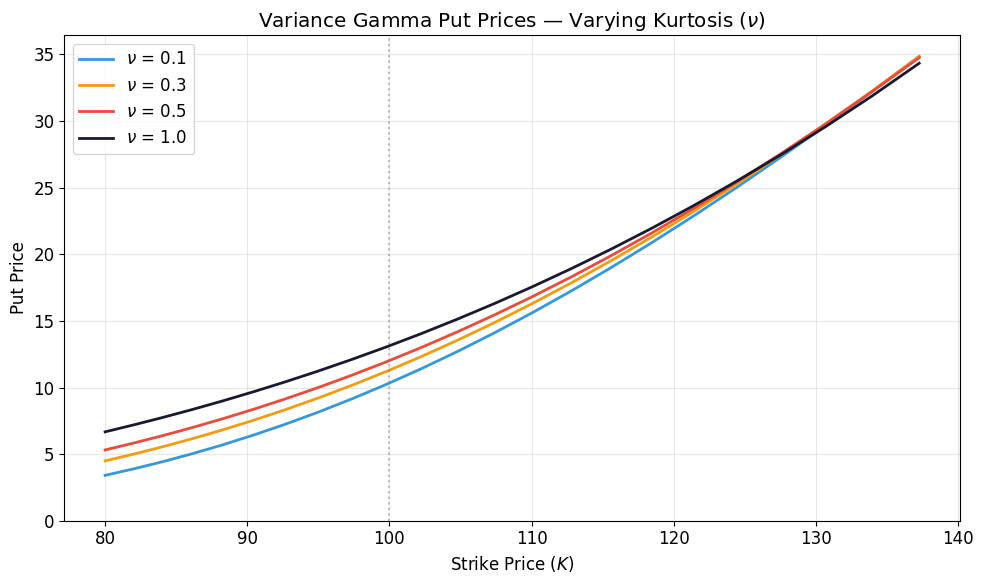

In [ ]:
nu_values = [0.1, 0.3, 0.5, 1.0]
colors_nu = ['#3498DB', '#F39C12', '#E74C3C', '#1A1A2E']

fig, ax = plt.subplots()
for nu_val, col in zip(nu_values, colors_nu):
    params_nu = [0.3, nu_val, -0.4]
    km_nu, prices_nu = genericFFT(params_nu, S0, K, r, q, T, alpha, eta, n, 'VG')
    strikes_nu = np.exp(km_nu)
    mask_nu = (strikes_nu >= k_min) & (strikes_nu <= k_max)
    ax.plot(strikes_nu[mask_nu], prices_nu[mask_nu], linewidth=2,
            label=f'$\\nu$ = {nu_val}', color=col)

ax.axvline(x=S0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Strike Price ($K$)')
ax.set_ylabel('Put Price')
ax.set_title('Variance Gamma Put Prices — Varying Kurtosis ($\\nu$)')
ax.legend()
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

---

# Part 5: Damping Factor ($\alpha$) Stability

The damping factor $\alpha$ is a numerical parameter, not a model parameter — it controls the convergence of the Fourier integral. Choosing it badly produces garbage prices.

**Why this matters:** In 2012, Knight Capital lost \$440 million in 45 minutes due to a software deployment error in their trading systems. While that was a code bug, not a numerical one, the lesson is the same: production pricing systems need to be robust. A quant who builds an FFT pricer without validating the numerical parameters is building a system that might silently produce nonsense for certain models or parameter regimes. This sweep is the kind of due diligence that separates a research prototype from a production tool.

**What to notice:** $\alpha = -1.01$ (too close to the pole at $-1$) blows up across all models. For VG, $\alpha = -5.0$ also fails because the characteristic function's strip of regularity is narrower. The safe zone is roughly $\alpha \in [-2, -1.25]$ for all three models.

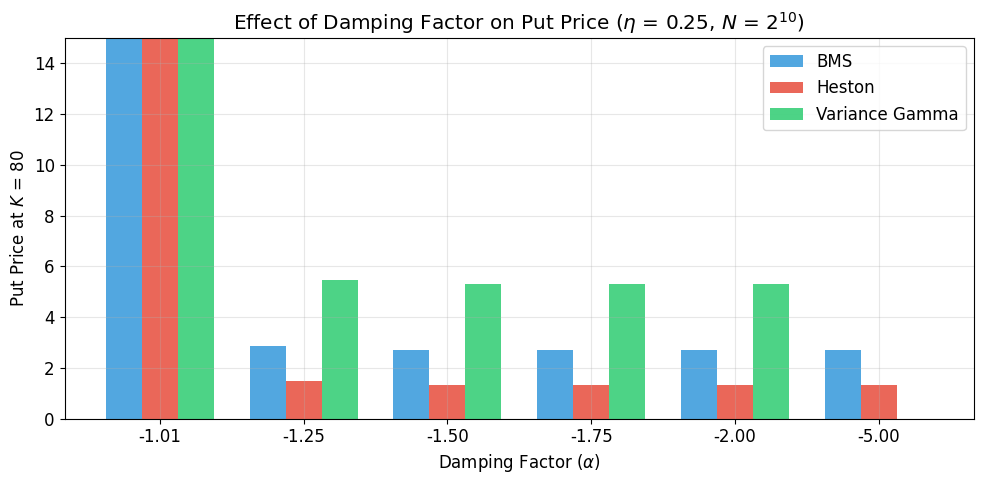

   alpha         BMS      Heston          VG
--------------------------------------------
   -1.01    269.0367    267.6698    271.6423
   -1.25      2.8504      1.4835      5.4560
   -1.50      2.7083      1.3414      5.3139
   -1.75      2.7080      1.3412      5.3137
   -2.00      2.7080      1.3412      5.3137
   -5.00      2.7080      1.3412      0.0020


In [ ]:
alpha_sweep = np.array([-1.01, -1.25, -1.5, -1.75, -2., -5.])
eta_sweep = np.array([0.1, 0.25])
n_sweep = np.array([6, 10])
models = ['BMS', 'Heston', 'VG']
all_params = {'BMS': bms_params, 'Heston': heston_params, 'VG': vg_params}

# compute prices for the best eta/n combination (0.25, 2^10)
results = {}
for mod in models:
    prices_alpha = []
    for a in alpha_sweep:
        km_a, p_a = genericFFT(all_params[mod], S0, K, r, q, T, a, 0.25, 10, mod)
        prices_alpha.append(p_a[0])  # price at K
    results[mod] = prices_alpha

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(alpha_sweep))
width = 0.25

bars1 = ax.bar(x_pos - width, results['BMS'], width, label='BMS', color='#3498DB', alpha=0.85)
bars2 = ax.bar(x_pos,         results['Heston'], width, label='Heston', color='#E74C3C', alpha=0.85)
bars3 = ax.bar(x_pos + width, results['VG'], width, label='Variance Gamma', color='#2ECC71', alpha=0.85)

ax.set_xticks(x_pos)
ax.set_xticklabels([f'{a:.2f}' for a in alpha_sweep])
ax.set_xlabel('Damping Factor ($\\alpha$)')
ax.set_ylabel('Put Price at $K$ = 80')
ax.set_title('Effect of Damping Factor on Put Price ($\\eta$ = 0.25, $N$ = $2^{10}$)')
ax.legend()
ax.set_ylim(0, 15)  # clip the blowups for readability
plt.tight_layout()
plt.show()

# print the actual values including blowups
print(f'{"alpha":>8}  {"BMS":>10}  {"Heston":>10}  {"VG":>10}')
print('-' * 44)
for i, a in enumerate(alpha_sweep):
    print(f'{a:8.2f}  {results["BMS"][i]:10.4f}  {results["Heston"][i]:10.4f}  {results["VG"][i]:10.4f}')

---

# Part 6: Full Sensitivity Tables

For completeness, here are the full sweep results across all combinations of $\eta$, $N$, and $\alpha$ for each model. These match the original analysis — now with the visual context to interpret them.

In [ ]:
def price_all_puts(params, S0, K, r, q, T, model, alpha_vec, eta_vec, n_vec):
    """Sweep over (eta, n, alpha) combinations and return put prices."""
    num_prices = len(eta_vec) * len(n_vec) * len(alpha_vec)
    put_matrix = np.zeros([num_prices, 4])
    i = 0
    for eta in eta_vec:
        for n in n_vec:
            for alpha in alpha_vec:
                k_vec, option_vec = genericFFT(params, S0, K, r, q, T, alpha, eta, n, model)
                put = option_vec[0]
                put_matrix[i] = np.array([eta, n, alpha, put])
                i += 1
    return put_matrix

for mod_name, mod_params in [('BMS', bms_params), ('Heston', heston_params), ('VG', vg_params)]:
    mat = price_all_puts(mod_params, S0, K, r, q, T, mod_name, alpha_sweep, eta_sweep, n_sweep)
    print(f'\nModel = {mod_name}')
    print(f'{"eta":>6}  {"N":>6}  {"alpha":>8}  {"put":>10}')
    print('-' * 36)
    for i in range(len(mat)):
        print(f'{mat[i,0]:6.2f}  2^{int(mat[i,1]):>3}  {mat[i,2]:8.2f}  {mat[i,3]:10.4f}')


Model = BMS
   eta       N     alpha         put
------------------------------------
  0.10  2^  6     -1.01     89.7431
  0.10  2^  6     -1.25      2.7396
  0.10  2^  6     -1.50      2.7569
  0.10  2^  6     -1.75      2.7701
  0.10  2^  6     -2.00      2.7789
  0.10  2^  6     -5.00      2.6727
  0.10  2^ 10     -1.01     89.7316
  0.10  2^ 10     -1.25      2.7080
  0.10  2^ 10     -1.50      2.7080
  0.10  2^ 10     -1.75      2.7080
  0.10  2^ 10     -2.00      2.7080
  0.10  2^ 10     -5.00      2.7080
  0.25  2^  6     -1.01    269.0367
  0.25  2^  6     -1.25      2.8504
  0.25  2^  6     -1.50      2.7083
  0.25  2^  6     -1.75      2.7080
  0.25  2^  6     -2.00      2.7080
  0.25  2^  6     -5.00      2.7080
  0.25  2^ 10     -1.01    269.0367
  0.25  2^ 10     -1.25      2.8504
  0.25  2^ 10     -1.50      2.7083
  0.25  2^ 10     -1.75      2.7080
  0.25  2^ 10     -2.00      2.7080
  0.25  2^ 10     -5.00      2.7080

Model = Heston
   eta       N     alpha         

---

## Key Takeaways

1. **The FFT is model-agnostic.** The same 20-line pricing function works for any model with a known characteristic function. Swapping models means swapping one function — not rewriting the pricer. This is why FFT-based engines are the backbone of production pricing libraries at banks and hedge funds.

2. **Models disagree in the tails — and the tails are where the money is.** Near-the-money, all three models produce similar prices. The differences live in the out-of-the-money region, which is exactly where portfolio hedges, tail risk strategies, and credit derivatives are priced. Choosing BMS when the market prices with fat-tailed models means systematically mispricing risk.

3. **Parameters have economic meaning.** Heston's $\rho$ captures the leverage effect that shows up in every equity market crash. VG's $\theta$ captures the directional asymmetry embedded in credit spreads. VG's $\nu$ captures the clustering of market activity that drives options prices during earnings season and Fed announcements. Understanding what each parameter *does* is more important than the formulas.

4. **Numerical choices matter as much as model choices.** The damping factor $\alpha$ is "just" a computational parameter, but choosing it wrong produces meaningless prices. In production systems, a silent numerical failure is more dangerous than a wrong model — at least a wrong model is consistently wrong. Always validate your numerical setup before trusting the output.

5. **No model is correct — but some are useful.** BMS is the common language of options markets. Heston is the workhorse for equity derivatives. VG captures jump behavior for credit and commodities. The real skill is knowing which model fits the problem you are solving and understanding the tradeoffs you are making.

---

### Sources
* Carr, P. and Madan, D. (1999). Option valuation using the fast Fourier transform. *Journal of Computational Finance*, 2(4), 61–73.
* [quant.opengamma.io/FourierPricing.pdf](https://quant.opengamma.io/FourierPricing.pdf)
* [pfadintegral.com — Option Pricing Formulae Using Fourier Transform](https://pfadintegral.com/articles/option-pricing-formulae-using-fourier-transform/)
* [Computational Methods in Pricing and Model Calibration — Columbia University](https://plus.columbia.edu/content/computational-methods-pricing-and-model-calibration)